The imports

In [1]:
import pygsti
import pygsti.modelmembers as mm
import numpy as np
import sympy as sp
from main_functions_github import *
from pygsti.modelpacks import smq2Q_XYCNOT, smq2Q_XYZZ
from pygsti.baseobjs import basis
import matplotlib.pyplot as plt
import scipy.stats as stats

**Gate model definition**

We first need to define classes for the gates present in our gate set. Let us start with the single-qubit gates, which are parameterized under a coloured noise model.

In [2]:
#operator class for the single-qubit gate

class G(pygsti.modelmembers.operations.DenseOperator):

    def __init__(self, markov_approx, intensity_noise, pulse_duration, phase, representation, gate_indices, gate_index, init_values = None):
        #initialize with no noise
        super(G, self).__init__(np.identity(4,'d'), 'pp', "densitymx") 
        
        self.markov_approx = markov_approx
        self.intensity_noise = intensity_noise
        self.pulse_duration = pulse_duration
        self.phase = phase
        self.representation = representation
        self.gate_indices = gate_indices
        self.gate_index = gate_index

        if init_values is None:
            init_values = [0, 1e-8]  # Default small values
            if not self.markov_approx:
                init_values.extend([0, 0])
            if self.intensity_noise:
                init_values.append(0)

        self.from_vector(init_values)

    def _num_params(self):
        if self.intensity_noise:
            return 3 if self.markov_approx else 5
        else:
            return 2 if self.markov_approx else 4
        
    #return the number of parameters
    @property
    def num_params(self):
        return self._num_params()

    #return the labels of the parameters
    @property
    def parameter_labels(self):
        gate_index1, gate_index2 = self.gate_indices[0], self.gate_indices[1]

        return [f'{"(G" + str(gate_index1 + 1) + ")" if self.gate_index == 0 else "G" + str(gate_index1 + 1)}'
                f'{"(G" + str(gate_index2 + 1) + ")" if self.gate_index == 1 else "G" + str(gate_index2 + 1)} param{i+1}' 
                for i in range(self._num_params())]

    #parameter bounds
    @property
    def parameter_bounds(self): #\Gamma_1 > 0 to ensure complete positivity of the matrices

        bounds = [(0, np.inf), (-np.inf, np.inf)]
        bounds.extend([(-np.inf, np.inf)] * (self._num_params() - 2))

        if self._num_params() == 3 or self._num_params() == 5:
            bounds[len(bounds) - 1] = (0, np.inf)

        return bounds
    
    def to_vector(self):

        vector = [self.Gamma_1, self.Delta_1]
        if not self.markov_approx:
            vector.append(self.Gamma_2)
            vector.append(self.Delta_2)
        if self.intensity_noise:
            vector.append(self.DeltaGamma)
            
        return np.array(vector, 'd')
        
    def from_vector(self, v, close = False, dirty_value = True):

        #initialize from parameter vector v
        self.Gamma_1, self.Delta_1 = v[0], v[1]
        self.Gamma_2, self.Delta_2, self.DeltaGamma = 0, 0, 0

        if not self.markov_approx:
            self.Gamma_2, self.Delta_2 = v[2], v[3]
        if self.intensity_noise:
            self.DeltaGamma = v[2 if self.markov_approx else 4]

        # we build the gate in the phase noise model using the function `build_gate_ptm'
        self._ptr[:,:] = build_gate_ptm(np.array([self.Gamma_1, self.Delta_1,  self.Gamma_2,  self.Delta_2, self.DeltaGamma], 'd'),
                                    self.pulse_duration, self.markov_approx, self.intensity_noise, phase = self.phase)

        self.dirty = dirty_value  # mark that parameter vector may have changed

    # This should be included if gauge optimization is performed
    # def transform(self, S):
    # # Update self with inverse(S) * self * S (used in gauge optimization)
    #     return self

Now we define the functions and the class for the two-qubit light shift gate including frequency and thermal errors.

In [3]:

# We define the \phi trajectory function present in the displacement operator
def phi(F, omega_mode, omega_laser, t):

    deltaX = omega_mode - omega_laser
    return F * (1/deltaX) * (1 - np.exp(1j * deltaX * t))

def phi_with_resonances(F, omega_mode, omega_laser, t):

    delta = omega_mode - omega_laser
    sum_frecs = omega_laser + omega_mode

    return F * ((1/delta) * (1 - np.exp(1j * delta * t)) + (1/sum_frecs) * (1 - np.exp( - 1j * sum_frecs * t)))

# spin-spin coupling J_{i,j}
def spin_spin_coupling(F, omega_laser, omega_modes, t):

    deltas = omega_modes - omega_laser
    sum_frecs = omega_laser + omega_modes

    J_values = 2 * np.real((F[0, :] * F[1, :])) * ( (1/deltas + 1/sum_frecs) * (- t) + 1/(deltas**2) * (- np.sin(deltas*t)) + 1/(sum_frecs**2) * (- np.sin(sum_frecs*t)) + \
        + 1 / (deltas*sum_frecs) * (sum_frecs + deltas)/(sum_frecs - deltas) * (- np.sin(sum_frecs*t)) + 1 / (deltas*sum_frecs) * (- np.sin(sum_frecs*t) - np.sin(deltas*t)))
    
    J = np.sum(J_values)

    return J

# In the context depenndent case, the displacement accumulation due to unclosed trajectories in phase space results in a phase term and a
# periodic contribution to the thermal parameter error. These contributions are given by the following two functions:

def thermal_phase_contribution_ZZ(phi_values, max_depth, omega_phonons, t):

    phi_ZZ = phi_values[1,1]
    omega_ZZ = omega_phonons[1]

    return 4 * np.abs(phi_ZZ) ** 2 * (max_depth * np.sin(omega_ZZ * t) - np.sin(max_depth * omega_ZZ * t)) / (2 * (1 - np.cos(omega_ZZ * t)))

def amplification_contribution_ZZ(phi_values, max_depth, omega_phonons, n_modes, t):

    phi_ZZ = phi_values[1,1]
    omega_ZZ = omega_phonons[1]
    n_ZZ = n_modes[1]

    return - ((np.cos(max_depth * omega_ZZ * t) - 1) / (np.cos(omega_ZZ * t) - 1)) * (np.abs(2 * phi_ZZ) ** 2) * (1/2 + n_ZZ)

# Dephasing channel 

Gamma_symbol = sp.Symbol('Gamma_symbol', real=True)
p_deph = sp.Symbol('p_deph', real=True)

DephasingEq = sp.Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 4 * Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4 * Gamma_symbol, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, Gamma_symbol, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

DephasingChannel = sp.exp(DephasingEq)

J = sp.Symbol('J', real=True)
omega_0, t = sp.symbols('omega_0, t', real=True, positive = True)

# ZZ interaction
# Uniray operator
ZZ_unitary = sp.Matrix(sp.cos(J) * np.kron(pauli_i, pauli_i) - 1j * sp.sin(J) * np.kron(pauli_z, pauli_z))

# Superoperator in natural representation
ZZ_channel = np.kron(ZZ_unitary, ZZ_unitary.conjugate())

#Z rotation
# Uniray operator
Z_unitary = sp.Matrix(np.kron(sp.cos(omega_0 * t) * pauli_i - 1j * sp.sin(omega_0 * t) * pauli_z, sp.cos(omega_0 * t) * pauli_i - 1j * sp.sin(omega_0 * t) * pauli_z))

# Superoperator in natural representation
Z_channel = np.kron(Z_unitary, Z_unitary.conjugate())

# variables
phi_1 = sp.Symbol('phi_1', real=True)
p_th = sp.Symbol('p_th', real=True)
phase_th_exponent = sp.Symbol('phase_th_exponent', real=True)
p2_th = sp.Symbol('p2_th')

# Spin-dependent displacement (superoperator)
SDD_channel = sp.Matrix([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, sp.exp(4 * phi_1), 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(4 * phi_1), 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, sp.exp(phi_1), 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

# Phase term from unclosed trajectories. This is equivalent to a redefinition of the spin-spin coupling.
additional_thermal_contribution_exponent = sp.Matrix([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, (1j) * p2_th, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, (1j) * p2_th, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, (-1j) * p2_th, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, (-1j) * p2_th, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, (-1j) * p2_th, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, (-1j) * p2_th, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, (1j) * p2_th, 0, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, (1j) * p2_th, 0],
                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

additional_thermal_contribution = sp.exp(additional_thermal_contribution_exponent)

# complete channel
complete_channel = sp.simplify(sp.Matrix(Z_channel@SDD_channel@ZZ_channel@DephasingChannel))

# we change of basis to the pauli basis to obtain the PTM representation
from_basis = basis.BuiltinBasis('std', 16)

basis_change_matrix = from_basis.create_transform_matrix('pp')
inv_basis_change_matrix = np.linalg.inv(basis_change_matrix)

# We compute the product of channels instead of the basis-transformed complete channel for simplification reasons 
channel_pp = sp.Matrix(sp.simplify(sp.Matrix(basis_change_matrix@Z_channel@inv_basis_change_matrix))) @\
             sp.Matrix(sp.simplify(sp.Matrix(basis_change_matrix@ZZ_channel@inv_basis_change_matrix))) @\
             sp.Matrix(sp.simplify(sp.Matrix(basis_change_matrix@additional_thermal_contribution@inv_basis_change_matrix))) @\
             sp.Matrix(sp.simplify(sp.Matrix(basis_change_matrix@SDD_channel@inv_basis_change_matrix))) @\
             sp.Matrix(sp.simplify(sp.Matrix(basis_change_matrix@DephasingChannel@inv_basis_change_matrix)))

# We redefine some variables
channel_pp = sp.Matrix(sp.simplify(channel_pp)).subs(sp.exp(Gamma_symbol), p_deph).subs(sp.exp(phi_1), p_th)

# we make a numpy version of the channel inside a function to define our gate model
channel_func = sp.lambdify((p_deph, p_th, p2_th, J, omega_0, t), channel_pp, 'numpy')

def channel_complete_two_qubits(p_deph, p_th, p2_th, J, omega_0, t):
    return np.array(channel_func(p_deph, p_th, p2_th, J, omega_0, t), dtype = np.float64)

channel_pp

Matrix([
[1.0,                                                  0,                                                  0,   0,                                                  0,                                             0,                                            0,                                                  0,                                                  0,                                            0,                                             0,                                                  0,   0,                                                  0,                                                  0,   0],
[  0,  1.0*p_deph*p_th*cos(2*omega_0*t)*cos(2*J - p2_th), -1.0*p_deph*p_th*sin(2*omega_0*t)*cos(2*J - p2_th),   0,                                                  0,                                             0,                                            0,                                                  0,                                                  0,    

Now we can define the LS class. Note that the 'gate' now is a sequnece of p LS gates. Therefore, the class takes a max_depth argument and some quantities are scaled by p, such as the spin-spin coupling. 

In [4]:
class LS(pygsti.modelmembers.operations.DenseOperator):

    def __init__(self, omega_0, omega_laser, omega_modes, F, phi_values_experiment, t, n_values, max_depth, init_value = None):
        #initialize with no noise
        super(LS, self).__init__(np.identity(16,'d'), 'pp', "densitymx")

        self.omega_0 = omega_0
        self.omega_laser = omega_laser
        self.omega_modes = omega_modes
        self.phi_values_experiment = phi_values_experiment
        self.F = F
        self.t = t
        self.max_depth = max_depth
        self.n_values = n_values

        if init_value is None:
            init_value = [1, 1]

        self.from_vector(init_value)

    def _num_params(self):
        return 2
    
    #return the number of parameters
    @property
    def num_params(self):
        return self._num_params()

    #parameter bounds
    @property
    def parameter_bounds(self): 

        bounds = [(0, 1.01), (0, 1.01)] # To avoid bias in the predicted scalings, we let the bounds slightly exceed the physical limits

        return bounds
    
    def to_vector(self):

        vector = [self.p_deph_parameter, self.p_thermal_parameter] 
            
        return np.array(vector, 'd')
        
    def from_vector(self, v, close = False, dirty_value = True):

        #initialize from parameter vector v
        self.p_deph_parameter = v[0] 
        self.p_thermal_parameter = v[1] 

        p_deph = self.p_deph_parameter 
        p_th = self.p_thermal_parameter 
        
        J = self.max_depth * spin_spin_coupling(self.F, self.omega_laser, self.omega_modes, self.t)
        p2_thermal = thermal_phase_contribution_ZZ(self.phi_values_experiment, self.max_depth, self.omega_modes, self.t)

        self._ptr[:,:] = channel_complete_two_qubits(p_deph, p_th, p2_thermal, J, self.omega_0, self.t)

        self.dirty = dirty_value  # mark that parameter vector may have changed

We define a theoretical model for GST, which consists on a set of single-qubit gates plus the LS gate.

In [5]:
num_qubits = 2

# For single-qubit gates, we consider no intensity noise and the markovian approximation. This can be modified at will.
markov_approx = True
intensity_noise = False

# Empty models
mdl_SPAM = pygsti.models.ExplicitOpModel(0,'pp')
mdl_complete = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')
mdl_complete_fully_general = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

# Single-qubit labels
myGates = ['G1', 'G2', 'G3', 'G4', 'G5']

# Phase and pulse duration parameters for the gates
gateSetParams = {'G1': [np.pi, 0], 
                 'G2': [np.pi / 2, 0],
                 'G3': [np.pi / 2, np.pi / 2],
                 'G4': [np.pi / 2, np.pi],
                 'G5': [np.pi / 2, 3 * np.pi / 2]}

# We call the class and make serialized versions of all posible gate combinations
for idx1, i in enumerate(myGates):
    for idx2, j in enumerate(myGates):
            
            Op1 = G(markov_approx, intensity_noise, *gateSetParams[i], 'PTM', [idx1, idx2], 0)
            Op2 = G(markov_approx, intensity_noise, *gateSetParams[j], 'PTM', [idx1, idx2], 1)

            mdl_complete.operations[(i + j, 0, 1)] = mm.operations.ComposedOp(
                                        (mm.operations.EmbeddedOp([0, 1], [0], Op1),
                                        mm.operations.EmbeddedOp([0, 1], [1], Op2))
                                        )
# To define the model, let us use the LS gate with p=1 (this will be changed later).
max_depth = 1

# Some physical paremeters

n_value_active, n_value_spectator = 5, 5 # phonons in each mode
n_values = [n_value_active, n_value_spectator]

omega_0 = max_depth * (2 * np.pi * 10.5) * 1e6
omega_modes = 1e6 * (2 * pi) * np.array([1.49, 2.57]) # Axial phonon mode frequencies
omega_laser = omega_modes[0] - 2 * np.pi / (95.3295 * 1e-6)
omega_rabi = 2 * np.pi * 50 * 1e3

t_gate = 2 * np.pi / (omega_modes[0] - omega_laser) # We set the time to close the COM mode trajectory

F = 23397.9839798398 * 1j/np.sqrt(2) * np.array([[1, 1],
                                          [1, -1]])

# We compute the values of the trajectory phi functions
phi_values_experiment = np.zeros((np.size(F, 0), np.size(F, 1)), dtype = complex)

for i in range(np.size(F, 0)):
    for m in range(np.size(F, 1)):
        phi_values_experiment[i, m] = phi_with_resonances(F[i, m], omega_modes[m], omega_laser, t_gate)

# We add the LS gate to the model
mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, max_depth)

# We define SPAM using tensor product of single-qubit components
mdl_SPAM[('rho0_1')] = mm.states.TPState( np.array([ 1/sqrt(2), 0, 0, 1/sqrt(2) ], 'd'), 
                                    evotype = 'densitymx')

mdl_SPAM[('rho0_2')] = mm.states.TPState( np.array([ 1/sqrt(2), 0, 0, 1/sqrt(2) ], 'd'), 
                                    evotype = 'densitymx')

mdl_SPAM[('Mdefault_1')] = mm.povms.TPPOVM(
                        {'0': [ 1/sqrt(2), 0, 0, 1/sqrt(2) ],   
                        '1': [ 1/sqrt(2), 0, 0, -1/sqrt(2) ] },
                        evotype = 'densitymx') 

mdl_SPAM[('Mdefault_2')] = mm.povms.TPPOVM(
                        {'0': [ 1/sqrt(2), 0, 0, 1/sqrt(2) ],   
                        '1': [ 1/sqrt(2), 0, 0, -1/sqrt(2) ] },
                        evotype = 'densitymx') 

mdl_complete[('rho0', 0, 1)] = mm.states.TensorProductState([mdl_SPAM[('rho0_1')], mdl_SPAM[('rho0_2')]], [0, 1])
mdl_complete[('Mdefault', 0, 1)] = mm.povms.TensorProductPOVM([mdl_SPAM[('Mdefault_1')], mdl_SPAM[('Mdefault_2')]], 
                                                        'densitymx')

print(mdl_complete.num_params)

116


In [6]:
# Let us check that the spin-spin coupling is apprix. pi/4.as_integer_ratio

J_experimental = spin_spin_coupling(F, omega_laser, omega_modes, t_gate)

print(J_experimental)
print(np.pi / 4)

0.7854008900816303
0.7853981633974483


Now we have to collect some parameters. We know that, for single qubit operations under this noise model, gates with same pulse duration share parameters, irrespective of the phases. Also, because we have defined serialized versions of all posible single-qubit gates, we need to collect parameters for those sets of two-qubit serialized gates with the same single-qubit gate in one of the two qubits, as we do not consider crosstalk for this example. We do it as follows

In [7]:
params_labels = mdl_complete.parameter_labels

# We first collect parameters from the non-crosstalk model
for i in myGates:
    collectable_params1, collectable_params2, collectable_params3, collectable_params4 = [], [], [], []
    for j in myGates:

        collectable_params1.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + j, 0, 1)].parameter_labels[0]][0]) 
        collectable_params2.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + j, 0, 1)].parameter_labels[1]][0]) 
        collectable_params3.append([element for element in params_labels if element[1] == mdl_complete.operations[(j + i, 0, 1)].parameter_labels[2]][0]) 
        collectable_params4.append([element for element in params_labels if element[1] == mdl_complete.operations[(j + i, 0, 1)].parameter_labels[3]][0]) 

    mdl_complete.collect_parameters(collectable_params1) # Name of the new parameter is by default set to the first collected parameter
    mdl_complete.collect_parameters(collectable_params2)
    mdl_complete.collect_parameters(collectable_params3)
    mdl_complete.collect_parameters(collectable_params4)

# We also collect parameters which are equal because of the physical modelling
collectable_params1, collectable_params2, collectable_params3, collectable_params4 = [], [], [], []
for i in myGates[1:]: # Last 4 gates share parameters bc have the same pulse duration
    collectable_params1.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + 'G1', 0, 1)].parameter_labels[0]][0])
    collectable_params2.append([element for element in params_labels if element[1] == mdl_complete.operations[(i + 'G1', 0, 1)].parameter_labels[1]][0]) 
    collectable_params3.append([element for element in params_labels if element[1] == mdl_complete.operations[('G1' + i, 0, 1)].parameter_labels[2]][0]) 
    collectable_params4.append([element for element in params_labels if element[1] == mdl_complete.operations[('G1' + i, 0, 1)].parameter_labels[3]][0]) 

mdl_complete.collect_parameters(collectable_params1)
mdl_complete.collect_parameters(collectable_params2)
mdl_complete.collect_parameters(collectable_params3)
mdl_complete.collect_parameters(collectable_params4)

# We again print the number of parameteres, which should be 24
print(mdl_complete.num_params)

24


/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/models/model.py:1006: UserWarning: Internal Model attributes are being rebuilt. This is likely because a modelmember has been either added or removed. If you have manually set parameter bounds values at the Model level (not the model member level), for example using the `set_parameter_bounds` method, these values will be overwritten by the parameter bounds found in each of the modelmembers.
  _warnings.warn(msg)


**Model for simulations**

Now that the theoretical model is finished, we define a experimental model to simulate results.

In [8]:
mdl_experimental = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

# Some noise parameters for the OU-noise simulations
c, tau = 2 * 1e7, 5 * 1e-4

# For this noise model, Gamma noise parameter can be computed exaclty.
def Gamma(c, tau, t):
    return - c * tau ** 2 / 2 * (t + tau * (np.exp( -t / tau) - 1))

# physical parameters
J_experimental = max_depth * spin_spin_coupling(F, omega_laser, omega_modes, t_gate)
phi_1_experimental = amplification_contribution_ZZ(phi_values_experiment, max_depth, omega_modes, n_values, t_gate)
p2_thermal = thermal_phase_contribution_ZZ(phi_values_experiment, max_depth, omega_modes, t_gate)
Gamma_value = Gamma(c, tau, t_gate)

mdl_experimental[('Gls', 0, 1)] = channel_complete_two_qubits(np.exp(Gamma_value), np.exp(phi_1_experimental), p2_thermal, J_experimental, omega_0, t_gate)

# For single qubit gates there is not exact closed form for the numerical parameters. Therefore, we need to 
# compute an average over stochastic trajectories

# Number of stochastic trajectories
Mnoise = 1e3 #Only for testing purpouses. To have an acceptable accuracy set at least Mnoise = 1e4

# Experimental single-qubit gates
mdl_single_qubit = pygsti.models.ExplicitOpModel([0],'pp')

for idx, gate in enumerate(myGates):
    mdl_single_qubit[(gate)] = chi2ptm(stochastic_matrices([gateSetParams[gate][1]], Mnoise, gateSetParams[gate][0], intensity_noise, [c], [tau], omega_rabi)[0])


for idx1, i in enumerate(myGates):
    for idx2, j in enumerate(myGates):
            
            Op1 = mdl_single_qubit[(i)]
            Op2 = mdl_single_qubit[(j)]

            mdl_experimental.operations[(i + j, 0, 1)] = mm.operations.ComposedOp(
                                        (mm.operations.EmbeddedOp([0, 1], [0], Op1),
                                        mm.operations.EmbeddedOp([0, 1], [1], Op2)))

# SPAM
mdl_experimental[('rho0', 0, 1)] = smq2Q_XYCNOT.target_model().preps[('rho0')]
mdl_experimental[('Mdefault', 0, 1)] = smq2Q_XYCNOT.target_model().povms['Mdefault']

/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/embeddedop.py:94: ComplexWarning: Casting complex values to real discards the imaginary part
  self._rep.base[:, :] = self.to_dense(on_space='minimal')
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/composedop.py:121: ComplexWarning: Casting complex values to real discards the imaginary part
  self._rep.base[:, :] = mx
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: divide by zero encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: overflow encountered in matmul
  res = matmul(transpose(vt), multiply(s[..., newaxis], transpose(u)))
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/numpy/linalg/linalg.py:2030: RuntimeWarning: inva

**Circuit selection**

We choose the circuits to employ for the GST protocol. From our precious work, we already know single-qubit gate circuits.

In [9]:
# We select max_lenght = 1 because the length of the gate sequence is already defined inside the class.
max_lenght_considered = [2**0]

single_qubit_circuits = [pygsti.circuits.Circuit([('G3G3', 0, 1)]) + pygsti.circuits.Circuit([('G1G1', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G3G3', 0, 1)]),
                           pygsti.circuits.Circuit([('G4G4', 0, 1)]) + pygsti.circuits.Circuit([('G1G1', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G1G1', 0, 1)]),
                           pygsti.circuits.Circuit([('G3G3', 0, 1)]) + pygsti.circuits.Circuit([('G2G2', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G3G3', 0, 1)]),
                           pygsti.circuits.Circuit([('G1G1', 0, 1)]) + pygsti.circuits.Circuit([('G2G2', 0, 1)]) ** max_lenght_considered[0] + pygsti.circuits.Circuit([('G2G2', 0, 1)]),
                         ]

Now, we slightly deviate the LS gate from the ideal version and compute the same circuits again. We will chose those fiducial pairs which exhibit a large variation of the experimental frequencies. Because we are working with a last-depth only design, we can choose the best fiducial pairs at each depth, which may differ from one depth to the next.

In [10]:
params_labels = mdl_complete.parameter_labels

# small parameter deviation
epsilon = 1e-3
selected_circuits = []

gates_list = [[i] for i in mdl_complete.operations.keys()]

sequence_length = 11 #log2 of the max number of gate repetitions we are going to use

# State preparation
prep_fiducials = gates_list.copy()
prep_fiducials = pygsti.circuits.to_circuits(prep_fiducials, line_labels=[0,1])

# Measurement
meas_fiducials = gates_list.copy()
meas_fiducials = pygsti.circuits.to_circuits(meas_fiducials, line_labels=[0,1])

#germs
germs = pygsti.circuits.to_circuits(gates_list, line_labels=[0,1])

# We will store circuits with similar frequencies.
selected_circuits_with_redundancies = selected_circuits.copy()

# We count how many more circuits we need to select.
ls_pairs = int(mdl_complete.num_params / 2 - len(single_qubit_circuits))

# We compute the fiducial pairs for each depth
fidPairs = [{} for _ in range(sequence_length)] 
for current_sequence_length in range(sequence_length):

    selected_circuits = single_qubit_circuits.copy()
    selected_circuits_with_redundancies = selected_circuits.copy()
    
    # We substitute the LS gate by the sequence of gates with desired depth
    mdl_complete[('Gls', 0, 1)] = LS((2 ** current_sequence_length) * (2 * np.pi * 10.5), omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, 2 ** current_sequence_length)

    # circuits
    listOfExperiments = pygsti.circuits.gstcircuits.create_lsgst_circuits(
                    gates_list, prep_fiducials, meas_fiducials, pygsti.circuits.to_circuits([[('Gls',0,1)]]), max_lenght_considered, include_lgst = False)


    # ideal data
    data_unperturbed = pygsti.data.simulate_data(mdl_complete, listOfExperiments, num_samples = 1,
                                         sample_error = 'none')

    # we compute the fiducials
    for i in range(ls_pairs):
        
        # We perturb the first LS parameter
        index = len(params_labels) - 2

        if i%2 == 0: # We perturb the second parameter LS instead half of the times
            index += 1

        # We define the variated parameters and the new deviated model
        params = mdl_complete.to_vector()
        new_params = np.copy(mdl_complete.to_vector())
        new_params[index] = new_params[index] + epsilon
        mdl_complete.from_vector(new_params)

        # List of experiments
        listOfExperiments = pygsti.circuits.gstcircuits.create_lsgst_circuits(
                    gates_list, prep_fiducials, meas_fiducials, pygsti.circuits.to_circuits([[('Gls',0,1)]]), max_lenght_considered, include_lgst = False)

        # Use only the circuits which have not been used already 
        listOfExperiments = [x for x in listOfExperiments if x not in selected_circuits_with_redundancies]

        # Data with perturbed model
        data_perturbed = pygsti.data.simulate_data(mdl_complete, listOfExperiments, num_samples = 1,
                                                sample_error = 'none')
        
        # We restore the original model
        mdl_complete.from_vector(params)
        
        # We compute the frequency diference between perturbed and unperturbed data.
        data_dif = {}
        for circ in listOfExperiments:
            data_dif[circ] = np.abs((data_perturbed[circ][('00',)] - data_unperturbed[circ][('00',)])) +\
                            np.abs((data_perturbed[circ][('01',)] - data_unperturbed[circ][('01',)])) +\
                            np.abs((data_perturbed[circ][('10',)] - data_unperturbed[circ][('10',)]))
        
        # We select the circuit with the maximum frequency difference
        selected_circuits.append(max(data_dif, key = data_dif.get))

        # It might be the case that we select a diferent circuit with the same theoreitical probaility as other already selected.
        # Therefore, we ignore circuits whose frequencies are similar to already chosen circuits.
        max_value = max(data_dif.values())
        maxpositions = [circ for circ, value in data_dif.items() if abs(value - max_value) <= 1e-8]
        selected_circuits_with_redundancies += maxpositions

    # Populate a fidPairs dictionary with the computed circuits
    fidPairs[current_sequence_length] = {}
    for i, germ in enumerate(germs):
        if germ not in fidPairs[current_sequence_length]:
            fidPairs[current_sequence_length][germ] = []
        for j, prep in enumerate(prep_fiducials):
            for k, meas in enumerate(meas_fiducials):
                circuit = prep + germ ** max_lenght_considered[0] + meas
                if circuit in selected_circuits:
                    fidPairs[current_sequence_length][germ].append((j, k))

**Run GST**

We run GST in a context-dependent manner. We treat the whole LS sequence of depth p as just one gate that we can recover by tomography. Then, because we know the specific dependence of gate channel with depth, we can recover the parameters for each of the p individual gate applications. To compare and measure distances, we will employ the parameters of the first LS gate.

In [11]:

# number of samples per circuit
shots = 1e4

# We iterate over many GST optimzations to get statistics
iterations = 10

# list of max lengths for long-sequence circutis
maxLengths = [1,2,4,8,16,32,64,128,256,512,1024]

# array to store results
results_vs_p = np.empty([len(maxLengths), iterations])

# some more distances to compare
results_vs_p2 = np.empty([len(maxLengths), iterations])
results_vs_p3 = np.empty([len(maxLengths), iterations])
results_vs_p4 = np.empty([len(maxLengths), iterations])

th_param = np.empty([len(maxLengths), iterations])
d_param = np.empty([len(maxLengths), iterations])

#some custom GST options
my_adv_options = {'tolerance': 1e-4,'starting_point': 'target', 'max_iterations': 1000,'min_prob_clip': 1/shots, 'use_freq_weighted_chi2': True}

# Gamma value at depth=1
Gamma_value_origin = Gamma(c, tau, t_gate)

# some empty models to be used later
mdl_experimental_depth1 = mdl_experimental.copy()
mdl_estimate_depth1 = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

for iter in range(iterations): 
    print(iter)

    for i, maxDepth in enumerate(maxLengths):

        # physical parameters which are depth-dependent
        omega_0 = maxDepth * (2 * np.pi * 10.5) * 1e6
        J_experimental = maxDepth * spin_spin_coupling(F, omega_laser, omega_modes, t_gate)
        Gamma_value = maxDepth * Gamma_value_origin
        phi_1_experimental = amplification_contribution_ZZ(phi_values_experiment, maxDepth, omega_modes, n_values, t_gate)
        p2_thermal = thermal_phase_contribution_ZZ(phi_values_experiment, maxDepth, omega_modes, t_gate)

        # Update the experimental gate sequence at each depth
        mdl_experimental[('Gls', 0, 1)] = channel_complete_two_qubits(np.exp(Gamma_value), np.exp(phi_1_experimental), p2_thermal, J_experimental, omega_0, t_gate)
        
        # Update the theoretical gate sequence at each depth
        mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, maxDepth)

        # the list of experiments to execute
        listOfExperiments0 = pygsti.circuits.gstcircuits.create_lsgst_circuits(
            mdl_experimental, prep_fiducials, meas_fiducials, germs, [maxDepth], include_lgst = False, fid_pairs = fidPairs[i])

        # At depth p, we substitute the p LS sequences that the long-sequence protocol includes by default in the circuits by
        # just one LS sequence, as it already contains the p repetition of the LS gates.
        listOfExperiments = []
        for index, germ in enumerate(listOfExperiments0):
            if germ[1] == ('Gls', 0, 1):
                listOfExperiments.append(listOfExperiments0[index][[0, 1, len(listOfExperiments0[0]) - 1]])
            else:
                listOfExperiments.append(listOfExperiments0[index])

        #simulate the data
        data = pygsti.data.simulate_data(mdl_experimental, listOfExperiments, num_samples = shots,
                                            sample_error = 'multinomial')

        #run lsGST
        results = pygsti.run_long_sequence_gst(data, mdl_complete, prep_fiducials, meas_fiducials,
                                            germs, [maxDepth], gauge_opt_params = False, advanced_options = my_adv_options, verbosity = 1)
        get_results = results.estimates['GateSetTomography']

        mdl_estimate = results.estimates['GateSetTomography'].models['final iteration estimate']

         #store the experimental channel at depth 1 to compute distances later
        if maxDepth == 1:
            mdl_experimental_depth1[('Gls', 0, 1)] = mdl_experimental[('Gls', 0, 1)]
            # store also the parameters needed for the estimated channel at depth 1
            p2_thermal_depth1, J_experimental_depth1, omega_0_depth1 = p2_thermal, J_experimental, omega_0

        # parameters at depth 1 estimated from the parameters for the complete channel 
        param1_depth1 = mdl_estimate[('Gls',0,1)].to_vector()[0] ** (1/maxDepth)
        param2_depth1 = np.log(mdl_estimate[('Gls',0,1)].to_vector()[1]) / (- ((np.cos(maxDepth * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1)) * (np.abs(2 * phi_values_experiment[1,1]) ** 2)) - 1 / 2

        exponent_param2_depth1 = (param2_depth1 + 1/2) * (- ((np.cos(1 * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1)) * (np.abs(2 * phi_values_experiment[1,1]) ** 2))

        # estimation for the channel at depth 1
        estimated_chanel_depth1 = channel_complete_two_qubits(param1_depth1, np.exp(exponent_param2_depth1), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
        estimated_chanel_depth1_idealparam1 = channel_complete_two_qubits(np.exp(Gamma_value_origin), np.exp(exponent_param2_depth1), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
        estimated_chanel_depth1_idealparam2 = channel_complete_two_qubits(param1_depth1, np.exp(amplification_contribution_ZZ(phi_values_experiment, 1, omega_modes, n_values, t_gate)), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
    
        # distances at depth 1
        results_vs_p[i, iter] = np.abs(exponent_param2_depth1 - amplification_contribution_ZZ(phi_values_experiment, 1, omega_modes, n_values, t_gate)) / np.abs(((np.cos(1 * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1))) 
        results_vs_p2[i, iter] = np.abs(param1_depth1 - np.exp(Gamma_value_origin))



/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/modelmembers/operations/composedop.py:342: ComplexWarning: Casting complex values to real discards the imaginary part
  v[factorgate_local_inds] = operation.to_vector()


0
--- Circuit Creation ---


/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/layouts/distlayout.py:1337: RuntimeWarning: divide by zero encountered in matmul
  atom_jtj[:, param_slice] = jT @ j  # _np.dot(jT, j)
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/layouts/distlayout.py:1337: RuntimeWarning: overflow encountered in matmul
  atom_jtj[:, param_slice] = jT @ j  # _np.dot(jT, j)
/opt/miniconda3/envs/coloured_GST/lib/python3.13/site-packages/pygsti/layouts/distlayout.py:1337: RuntimeWarning: invalid value encountered in matmul
  atom_jtj[:, param_slice] = jT @ j  # _np.dot(jT, j)


--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---


--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
1
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##########

...

--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
8
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- I

--- Iterative GST: [##################################################] 100.0%  12 circuits ---


--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
9
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- I

--- Iterative GST: [##################################################] 100.0%  12 circuits ---


--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  12 circuits ---


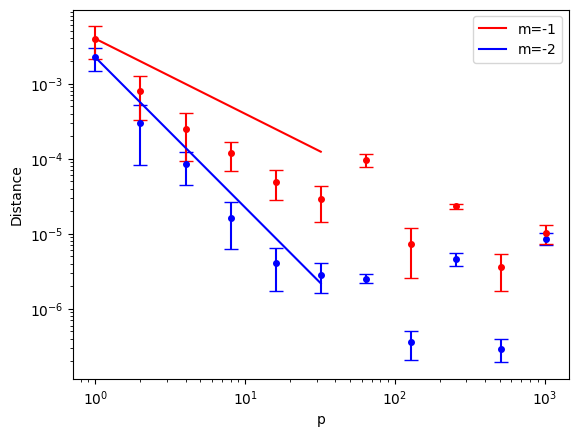

In [12]:
#we average ethe results over the iterations
distances_thermal = results_vs_p.mean(axis = 1)
distances_dephasing = results_vs_p2.mean(axis = 1)

# Error bar quantities

means_thermal = np.mean(results_vs_p, axis=1)
sem_thermal = stats.sem(results_vs_p, axis=1) 
conf_interval_thermal = stats.t.ppf(0.975, df = results_vs_p.shape[1]-1) * sem_thermal

means_dephasing = np.mean(results_vs_p2, axis=1)
sem_dephasing = stats.sem(results_vs_p2, axis=1) 
conf_interval_dephasing = stats.t.ppf(0.975, df = results_vs_p2.shape[1]-1) * sem_dephasing

# Creating the log-log plot
#plt.loglog(maxLengths, distances_thermal, marker='o', linestyle='-', color='r', label = 'data')
plt.errorbar(maxLengths, means_thermal, yerr = conf_interval_thermal, fmt='.', capsize=5, color='b', markersize=8)

#plt.loglog(maxLengths, distances_dephasing, marker='o', linestyle='-', color='b', label = 'data')
plt.errorbar(maxLengths, means_dephasing, yerr = conf_interval_dephasing, fmt='.', capsize=5, color='r', markersize=8)

# m=-1 expected slope
plt.loglog(maxLengths[0:6], distances_dephasing[0]/np.array(maxLengths[0:6]), color='red', label = 'm=-1')
plt.loglog(maxLengths[0:6], distances_thermal[0]/np.array(maxLengths[0:6]) ** 2, color='blue', label = 'm=-2')

# Labels and title
plt.xlabel('p')
plt.ylabel('Distance')
plt.legend()

plt.show()

Unfortunately, these results do not allow for a very neat interpretation. To get a better understanding of what is going on, let us employ all possible fiducial pairs with the LS gate.

In [13]:
ls_fp = []
for i in range(len(prep_fiducials)):
    for j in range(len(meas_fiducials)):
        ls_fp.append((i,j))

for i in range(len(fidPairs)):
    fidPairs[i][pygsti.circuits.Circuit([('Gls',0,1)])] = ls_fp

This will take a while

In [14]:

# number of samples per circuit
shots = 1e4

# We iterate over many GST optimzations to get statistics
iterations = 10

# list of max lengths for long-sequence circutis
maxLengths = [1,    2,    4,   8,   16, 32, 64, 128,  200, 256, 300, 310, 320, 352,  421,  502, 620, 630, 640, 650, 717,  857, 900, 910, 920, 930, 1024] 

# array to store results
results_vs_p = np.empty([len(maxLengths), iterations])

# some more distances to compare
results_vs_p2 = np.empty([len(maxLengths), iterations])
results_vs_p3 = np.empty([len(maxLengths), iterations])
results_vs_p4 = np.empty([len(maxLengths), iterations])

th_param = np.empty([len(maxLengths), iterations])
d_param = np.empty([len(maxLengths), iterations])

#some custom GST options
my_adv_options = {'tolerance': 1e-4,'starting_point': 'target', 'max_iterations': 1000,'min_prob_clip': 1/shots, 'use_freq_weighted_chi2': True}

# Gamma value at depth=1
Gamma_value_origin = Gamma(c, tau, t_gate)

# some empty models to be used later
mdl_experimental_depth1 = mdl_experimental.copy()
mdl_estimate_depth1 = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

for iter in range(iterations): 
    print(iter)

    for i, maxDepth in enumerate(maxLengths):

        # physical parameters which are depth-dependent
        omega_0 = maxDepth * (2 * np.pi * 10.5) * 1e6
        J_experimental = maxDepth * spin_spin_coupling(F, omega_laser, omega_modes, t_gate)
        Gamma_value = maxDepth * Gamma_value_origin
        phi_1_experimental = amplification_contribution_ZZ(phi_values_experiment, maxDepth, omega_modes, n_values, t_gate)
        p2_thermal = thermal_phase_contribution_ZZ(phi_values_experiment, maxDepth, omega_modes, t_gate)

        # Update the experimental gate sequence at each depth
        mdl_experimental[('Gls', 0, 1)] = channel_complete_two_qubits(np.exp(Gamma_value), np.exp(phi_1_experimental), p2_thermal, J_experimental, omega_0, t_gate)
        
        # Update the theoretical gate sequence at each depth
        mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, maxDepth)

        # the list of experiments to execute
        listOfExperiments0 = pygsti.circuits.gstcircuits.create_lsgst_circuits(
            mdl_experimental, prep_fiducials, meas_fiducials, germs, [maxDepth], include_lgst = False, fid_pairs = fidPairs[0])

        # At depth p, we substitute the p LS sequences that the long-sequence protocol includes by default in the circuits by
        # just one LS sequence, as it already contains the p repetition of the LS gates.
        listOfExperiments = []
        for index, germ in enumerate(listOfExperiments0):
            if germ[1] == ('Gls', 0, 1):
                listOfExperiments.append(listOfExperiments0[index][[0, 1, len(listOfExperiments0[0]) - 1]])
            else:
                listOfExperiments.append(listOfExperiments0[index])

        #simulate the data
        data = pygsti.data.simulate_data(mdl_experimental, listOfExperiments, num_samples = shots,
                                            sample_error = 'multinomial')

        #run lsGST
        results = pygsti.run_long_sequence_gst(data, mdl_complete, prep_fiducials, meas_fiducials,
                                            germs, [maxDepth], gauge_opt_params = False, advanced_options = my_adv_options, verbosity = 1)
        get_results = results.estimates['GateSetTomography']

        mdl_estimate = results.estimates['GateSetTomography'].models['final iteration estimate']

         #store the experimental channel at depth 1 to compute distances later
        if maxDepth == 1:
            mdl_experimental_depth1[('Gls', 0, 1)] = mdl_experimental[('Gls', 0, 1)]
            # store also the parameters needed for the estimated channel at depth 1
            p2_thermal_depth1, J_experimental_depth1, omega_0_depth1 = p2_thermal, J_experimental, omega_0

        # parameters at depth 1 estimated from the parameters for the complete channel 
        param1_depth1 = mdl_estimate[('Gls',0,1)].to_vector()[0] ** (1/maxDepth)
        param2_depth1 = np.log(mdl_estimate[('Gls',0,1)].to_vector()[1]) / (- ((np.cos(maxDepth * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1)) * (np.abs(2 * phi_values_experiment[1,1]) ** 2)) - 1 / 2

        exponent_param2_depth1 = (param2_depth1 + 1/2) * (- ((np.cos(1 * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1)) * (np.abs(2 * phi_values_experiment[1,1]) ** 2))

        # estimation for the channel at depth 1
        estimated_chanel_depth1 = channel_complete_two_qubits(param1_depth1, np.exp(exponent_param2_depth1), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
        estimated_chanel_depth1_idealparam1 = channel_complete_two_qubits(np.exp(Gamma_value_origin), np.exp(exponent_param2_depth1), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
        estimated_chanel_depth1_idealparam2 = channel_complete_two_qubits(param1_depth1, np.exp(amplification_contribution_ZZ(phi_values_experiment, 1, omega_modes, n_values, t_gate)), p2_thermal_depth1, J_experimental_depth1, omega_0_depth1, t_gate)
    
        # distances at depth 1
        results_vs_p[i, iter] = np.abs(exponent_param2_depth1 - amplification_contribution_ZZ(phi_values_experiment, 1, omega_modes, n_values, t_gate)) / np.abs(((np.cos(1 * omega_modes[1] * t_gate) - 1) / (np.cos(omega_modes[1] * t_gate) - 1))) 
        results_vs_p2[i, iter] = np.abs(param1_depth1 - np.exp(Gamma_value_origin))



0
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation ---
--- Iterative GST: [##################################################] 100.0%  680 circuits ---
--- Circuit Creation -

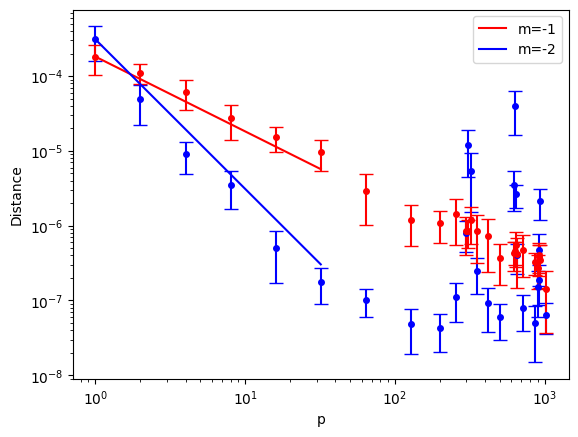

In [15]:
#we average ethe results over the iterations
distances_thermal = results_vs_p.mean(axis = 1)
distances_dephasing = results_vs_p2.mean(axis = 1)

# Error bar quantities

means_thermal = np.mean(results_vs_p, axis=1)
sem_thermal = stats.sem(results_vs_p, axis=1) 
conf_interval_thermal = stats.t.ppf(0.975, df = results_vs_p.shape[1]-1) * sem_thermal

means_dephasing = np.mean(results_vs_p2, axis=1)
sem_dephasing = stats.sem(results_vs_p2, axis=1) 
conf_interval_dephasing = stats.t.ppf(0.975, df = results_vs_p2.shape[1]-1) * sem_dephasing

# Creating the log-log plot
#plt.loglog(maxLengths, distances_thermal, marker='o', linestyle='-', color='r', label = 'data')
plt.errorbar(maxLengths, means_thermal, yerr = conf_interval_thermal, fmt='.', capsize=5, color='b', markersize=8)

#plt.loglog(maxLengths, distances_dephasing, marker='o', linestyle='-', color='b', label = 'data')
plt.errorbar(maxLengths, means_dephasing, yerr = conf_interval_dephasing, fmt='.', capsize=5, color='r', markersize=8)

# m=-1 expected slope
plt.loglog(maxLengths[0:6], distances_dephasing[0]/np.array(maxLengths[0:6]), color='red', label = 'm=-1')
plt.loglog(maxLengths[0:6], distances_thermal[0]/np.array(maxLengths[0:6]) ** 2, color='blue', label = 'm=-2')

# Labels and title
plt.xlabel('p')
plt.ylabel('Distance')
plt.legend()

plt.show()

The tendency in the previous figure is a bit more smooth due to the robust design obtained with the overcomplete fiducial pairs. Before analyzing those results, let us also compute the Fisher Information estimates of the achievable error bounds with this experimental design. For that, we compute the Fisher Information matrix at every depth and then analyze its spectrum. First, we need to redefine the LS gate class so that the parameters are the appropiate ones to take the derivatives (remember that the Fisher Information matrix is essentially a second-order derivative matrix of each circuit with respect to the parameters employed).

In [16]:
class LS(pygsti.modelmembers.operations.DenseOperator):

    def __init__(self, omega_0, omega_laser, omega_modes, F, phi_values_experiment, t, n_values, max_depth, init_value = None):
        #initialize with no noise
        super(LS, self).__init__(np.identity(16,'d'), 'pp', "densitymx") # this is *super*-operator, so "densitymx_slow"

        self.omega_0 = omega_0
        self.omega_laser = omega_laser
        self.omega_modes = omega_modes
        self.phi_values_experiment = phi_values_experiment
        self.F = F
        self.t = t
        self.max_depth = max_depth
        self.n_values = n_values

        if init_value is None:
            init_value = [np.exp(-2.1341684251218482e-05), 5.5 * np.abs( 2 * phi_values_experiment[1,1]) ** 2] # The FI matrix is defined at the target parameter's values
                                                                                                               # Because errors are small, we could use the unitary parameters aswell.

        self.from_vector(init_value)

    def _num_params(self):
        return 2
    
    #return the number of parameters
    @property
    def num_params(self):
        return self._num_params()

    #parameter bounds
    @property
    def parameter_bounds(self): 

        bounds = [(0, 1), (0, np.inf)] 

        return bounds
    
    def to_vector(self):

        vector = [self.p_depth_parameter, self.p_thermal_parameter] 
            
        return np.array(vector, 'd')
        
    def from_vector(self, v, close = False, dirty_value = True):

        #initialize from parameter vector v
        self.p_depth_parameter = v[0] 
        self.p_thermal_parameter = v[1] 
        
        # Correct parameters to visualize the amplificatino with depth
        p_depth = self.p_depth_parameter ** self.max_depth
        p_th = np.exp(- self.p_thermal_parameter * ((np.cos(self.max_depth * self.omega_modes[1] * self.t) - 1) / (np.cos(self.omega_modes[1] * self.t) - 1))) #np.exp(amplification_contribution_ZZ(self.phi_values_experiment, self.max_depth, self.omega_modes, [10, self.p_thermal_parameter], self.t))

        J = self.max_depth * spin_spin_coupling(self.F, self.omega_laser, self.omega_modes, self.t)
        p2_thermal = thermal_phase_contribution_ZZ(self.phi_values_experiment, self.max_depth, self.omega_modes, self.t)

        self._ptr[:,:] = channel_complete_two_qubits(p_depth, p_th, p2_thermal, J, self.omega_0, self.t)

        self.dirty = dirty_value  # mark that parameter vector may have changed

Now, becasue the model has many free parameters, analyzing the Fisher Information spectrum is not straightforward. We are interested here in the scaling of precision with depth for the LS parameters. The mentioned matrix will have one eigenvalue per free-parameter in our model. This means that, from one depth to the next, the ordering of the eigenvalues might change and we cannot easily keep track of the eigenvalues we are interested in. Rigorously, one would have to carefully address this issue. In this tutorial, however, to keep things simple, we define a new model in which only the LS has free parameters, and all other gates are pre-defined with fixed parameters. In this way, the Fisher Infromation matrix will only have the two eigenvalues we are interested in. Let me also note that results from both approaches are essentially the same.

We define our new model for the FI analysis

In [17]:
num_qubits = 2

mdl_SPAM = pygsti.models.ExplicitOpModel(0,'pp')
mdl_complete = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')
mdl_complete_fully_general = pygsti.models.ExplicitOpModel(range(num_qubits),'pp')

# Single-qubit gates
for idx1, i in enumerate(myGates):
    for idx2, j in enumerate(myGates):

            Op1 = mdl_single_qubit[(i)]
            Op2 = mdl_single_qubit[(j)]

            # Static operations
            mdl_complete.operations[(i + j, 0, 1)] = mm.operations.StaticArbitraryOp(mm.operations.ComposedOp(
                                        (mm.operations.EmbeddedOp([0, 1], [0], Op1),
                                        mm.operations.EmbeddedOp([0, 1], [1], Op2))
                                        ).to_dense())

# The new LS gate
mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, max_depth)

# Static SPAM
mdl_complete[('rho0', 0, 1)] = mm.states.StaticState(smq2Q_XYZZ.target_model().preps[('rho0')])
mdl_complete[('Mdefault', 0, 1)] = mm.povms.UnconstrainedPOVM(
                        {'00': mm.povms.StaticPOVMEffect(smq2Q_XYZZ.target_model().povms['Mdefault']['00'].to_vector()),   
                         '01': mm.povms.StaticPOVMEffect(smq2Q_XYZZ.target_model().povms['Mdefault']['01'].to_vector()),
                         '10': mm.povms.StaticPOVMEffect(smq2Q_XYZZ.target_model().povms['Mdefault']['10'].to_vector()),
                         '11': mm.povms.StaticPOVMEffect(smq2Q_XYZZ.target_model().povms['Mdefault']['11'].to_vector()) },
                        evotype = 'densitymx') 

print(mdl_complete.num_params)

2


We get the FI values

In [18]:
eigenvalues = []

for i, maxDepth in enumerate(range(1, 1024)):

    omega_0 = maxDepth * (2 * np.pi * 10.5) * 1e6
    
    # the list of experiments to execute
    listOfExperiments0 = pygsti.circuits.gstcircuits.create_lsgst_circuits(
        mdl_complete, prep_fiducials, meas_fiducials, germs, [1], include_lgst = False, fid_pairs = fidPairs[0])

    listOfExperiments = []
    
    for index, germ in enumerate(listOfExperiments0):
        if germ[1] == ('Gls', 0, 1):
            listOfExperiments.append(listOfExperiments0[index][[0, 1, len(listOfExperiments0[0]) - 1]])
        else:
            listOfExperiments.append(listOfExperiments0[index])


    mdl_complete[('Gls', 0, 1)] = LS(omega_0, omega_laser, omega_modes, F, phi_values_experiment, t_gate, n_values, maxDepth)

    # Fisher information analysis
    fi_matrix = pygsti.tools.calculate_fisher_information_matrix(mdl_complete, listOfExperiments, shots)

    eigenvalues.append(np.linalg.eigvals(fi_matrix))

    #print(i)

In [19]:
eigenvalue_thermal, eigenvalue_dephasing = [], []

for i in eigenvalues:
    eigenvalue_dephasing.append(i[0])
    eigenvalue_thermal.append(i[1])

We obtain the error bounds as the inverse of the square root of the eigenvalues.

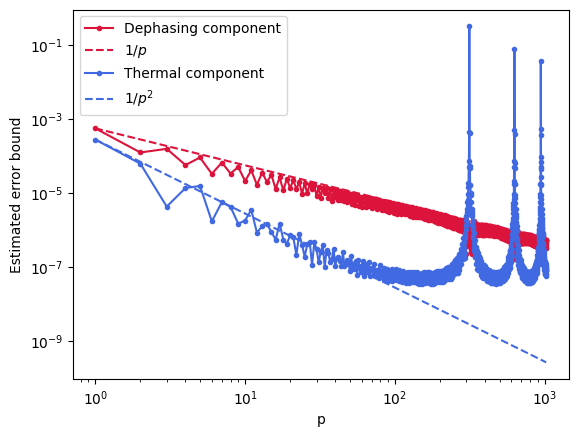

In [20]:
maxLengths_dense = range(1,1024) 

plt.loglog(maxLengths_dense, 1 / np.sqrt(np.array(eigenvalue_dephasing)), '.-', color= 'crimson', label = 'Dephasing component')
plt.loglog(maxLengths_dense,  1 / np.sqrt(np.array(eigenvalue_dephasing[0])) * 1 / np.array(maxLengths_dense), '--', color = 'crimson', label = '$1/p$')

plt.loglog(maxLengths_dense, 1 / np.sqrt(np.array(eigenvalue_thermal)), '.-', color= 'royalblue', label = 'Thermal component')
plt.loglog(maxLengths_dense, 1 / np.sqrt(np.array(eigenvalue_thermal[0])) * 1 / np.array(maxLengths_dense) ** 2, '--', color = 'royalblue', label = '$1/p^2$')

plt.xlabel('p')
plt.ylabel('Estimated error bound')
plt.legend()
  
plt.show()

Let us finally plot this with the previous distances in a single plot to check that the scaling is consistent.

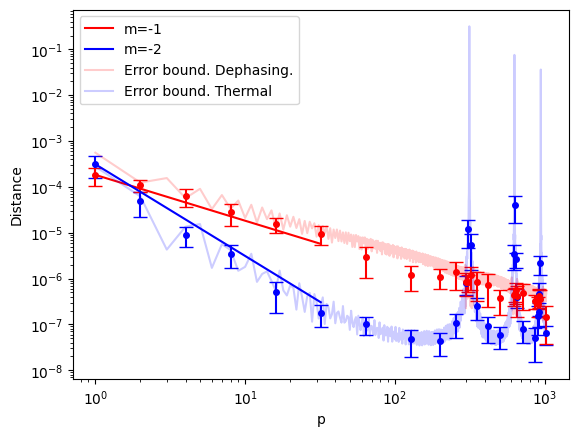

In [21]:
maxLengths = [1,    2,    4,   8,   16, 32, 64, 128,  200, 256, 300, 310, 320, 352,  421,  502, 620, 630, 640, 650, 717,  857, 900, 910, 920, 930, 1024] 

# Creating the log-log plot
plt.errorbar(maxLengths, means_thermal, yerr = conf_interval_thermal, fmt='.', capsize=5, color='b', markersize=8)

plt.errorbar(maxLengths, means_dephasing, yerr = conf_interval_dephasing, fmt='.', capsize=5, color='r', markersize=8)

# m=-1 expected slope
plt.loglog(maxLengths[0:6], distances_dephasing[0]/np.array(maxLengths[0:6]), color='red', label = 'm=-1')
plt.loglog(maxLengths[0:6], distances_thermal[0]/np.array(maxLengths[0:6]) ** 2, color='blue', label = 'm=-2')

plt.loglog(maxLengths_dense, 1 / np.sqrt(np.array(eigenvalue_dephasing)), alpha = 0.2, color= 'red', label = 'Error bound. Dephasing.')
plt.loglog(maxLengths_dense, 1 / np.sqrt(np.array(eigenvalue_thermal)), alpha = 0.2, color= 'blue', label = 'Error bound. Thermal')

# Labels and title
plt.xlabel('p')
plt.ylabel('Distance')
plt.legend()

plt.show()

As discussed in the manuscript, the thermal parameter scales as 1/depth^2 for short depths, beyond the 1/depth scaling of the standard-GST limit. This behaviour is reverted until phase-space trajectories close, where no infromation can be obtained about this parameter (spikes in the figure). Nonetheless, this region can be controlled by tuning trap parameters.